In [1]:
import time
import numpy as np
import pandas as pd
from IPython.display import clear_output

import matplotlib as mpl
import matplotlib.pyplot as plt

from numpy.polynomial.legendre import leggauss

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import LinearOperator, cg
from scipy.linalg import inv, solve, eigh, pinv
from scipy.interpolate import BarycentricInterpolator

from utils import make_boundary_hhalf_matrix_numpy

In [4]:
mpl.rcParams.update(
    {
        "font.size": 22,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 18,
        "legend.fontsize": 16,
        "lines.linewidth": 3,
    }
)

In [ ]:
# --- Alternative: load data ---
df = pd.read_csv("results/random_sampling.csv")

columns = [
    "SINOS_direct",
    "D_SINOS_direct",
    "SINOS_pinv",
    "D_SINOS_pinv",
    "SINOS_CG5",
    "D_SINOS_CG5",
]

results = df[columns].to_numpy()
times = df[[f"{c}_time_ms" for c in columns]].to_numpy()

In [5]:
# --- Parameters ---
nx, ny = 35, 35
n = (nx + 1) * (ny + 1)

In [6]:
# --- 1D setup ---
from utils import leggauss_diff

x_grid, wx = leggauss(nx+1)
y_grid, wy = leggauss(ny+1)

dx = leggauss_diff(x_grid)
dy = leggauss_diff(y_grid)

dx_s = (1 / wx).reshape(-1, 1) * (dx.T) * wx
dy_s = (1 / wy).reshape(-1, 1) * dy.T * wy

In [7]:
# --- 2D tensor-product operators ---
Wxy = np.diag(np.kron(wy, wx))
Wxy_inv = inv(Wxy)

Ix = np.eye(nx + 1)
Iy = np.eye(ny + 1)

Dx = np.kron(Iy, dx)
Dy = np.kron(dy, Ix)
Dxx = Dx @ Dx
Dxy = Dx @ Dy
Dyy = Dy @ Dy
Lap = Dxx + Dyy

X, Y = np.meshgrid(x_grid, y_grid, indexing="ij")

B_H1 = Wxy + Dx.T @ Wxy @ Dx + Dy.T @ Wxy @ Dy
B_H2 = B_H1 + Dxx.T @ Wxy @ Dxx + Dxy.T @ Wxy @ Dxy + Dyy.T @ Wxy @ Dyy

B_H1 = 0.5 * (B_H1 + B_H1.T)
B_H2 = 0.5 * (B_H2 + B_H2.T)

In [8]:
# --- Boundary grid ---
left = np.stack([-np.ones(ny + 1), y_grid], axis=1)
right = np.stack([np.ones(ny + 1), y_grid], axis=1)
bottom = np.stack([x_grid, -np.ones(nx + 1)], axis=1)
top = np.stack([x_grid, np.ones(nx + 1)], axis=1)

X_bc = np.vstack([left, right, bottom, top])

In [9]:
# --- Boundary weights ---
w_bc = np.concatenate([wy, wy, wx, wx])
W_bc = np.diag(w_bc)

W_bc_half = make_boundary_hhalf_matrix_numpy(
    X_bc,
    W_bc,
    boundary_dim=1,
)

In [10]:
# --- Trace matrix ---
interp_x = BarycentricInterpolator(x_grid, Ix, axis=0)
interp_y = BarycentricInterpolator(y_grid, Iy, axis=0)

trace_x_left = interp_x(-1.0)[None, :]
trace_x_right = interp_x(1.0)[None, :]
trace_y_bottom = interp_y(-1.0)[None, :]
trace_y_top = interp_y(1.0)[None, :]

T_left = np.kron(Iy, trace_x_left)
T_right = np.kron(Iy, trace_x_right)
T_bottom = np.kron(trace_y_bottom, Ix)
T_top = np.kron(trace_y_top, Ix)

T_bc = np.vstack([T_left, T_right, T_bottom, T_top])

In [11]:
# --- Hmats ---
Ixy = np.kron(Iy, Ix)
Dx_s = np.kron(Iy, dx_s)
Dy_s = np.kron(dy_s, Ix)

Hmat = Ixy + Dx_s @ Dx + Dy_s @ Dy
Hmat_s = Ixy + Dx @ Dx_s + Dy @ Dy_s
Hmat = 0.5 * (Hmat + Wxy_inv @ Hmat.T @ Wxy)
Hmat_s = 0.5 * (Hmat_s + Wxy_inv @ Hmat_s.T @ Wxy)

In [12]:
# --- Pseudoinverses ---
Hmat_pinv = pinv(Hmat)
Hmat_s_pinv = pinv(Hmat_s)

In [13]:
# --- CG Hmats ---
Ixy_sp = csr_matrix(Ixy)
Wxy_sp = csr_matrix(Wxy)
Dx_sp, Dy_sp = csr_matrix(Dx), csr_matrix(Dy)
Dx_s_sp, Dy_s_sp = csr_matrix(Dx_s), csr_matrix(Dy_s)

Hmat_sp = Ixy_sp + Dx_s_sp @ Dx_sp + Dy_s_sp @ Dy_sp
Hmat_sp_s = Ixy_sp + Dx_sp @ Dx_s_sp + Dy_sp @ Dy_s_sp

Hmat_sp_diag = Hmat_sp.diagonal()
Hmat_sp_s_diag = Hmat_sp_s.diagonal()

M_sp = LinearOperator((n, n), matvec=lambda v: v / Hmat_sp_diag, dtype=np.float64)
M_sp_s = LinearOperator((n, n), matvec=lambda v: v / Hmat_sp_s_diag, dtype=np.float64)

In [14]:
from utils import make_boundary_hhalf_matrix_numpy
W_bc_half = make_boundary_hhalf_matrix_numpy(
    X_bc,
    W_bc,
    boundary_dim=1,
)

In [15]:
times = []
results = []
for k in range(10_000):
    # Print progress
    clear_output(wait=True)
    print(k)

    # Generate a random vector with random sparsity level p
    p = np.random.rand()
    mask = np.random.rand(n) < p
    if not np.any(mask):
        mask[np.random.randint(n)] = True
    x = np.zeros(n)
    x[mask] = np.random.rand(np.sum(mask))
    x /= np.sqrt(x @ (B_H1 @ x))

    # Precomputations
    lap_x = Lap @ x
    trace_x = T_bc @ x
    boundary_sq = trace_x @ W_bc_half @ trace_x

    # Direct
    t0_neg_norm = time.perf_counter()
    interior_sq = lap_x @ Wxy @ solve(Hmat, lap_x)
    x_neg_norm = np.sqrt(interior_sq + boundary_sq)
    t1_neg_norm = time.perf_counter() - t0_neg_norm

    t0_dual_neg_norm = time.perf_counter()
    interior_sq = lap_x @ Wxy @ solve(Hmat_s, lap_x)
    x_dual_neg_norm = np.sqrt(interior_sq + boundary_sq)
    t1_dual_neg_norm = time.perf_counter() - t0_dual_neg_norm

    # Pseudoinverse
    t0_neg_norm_pinv = time.perf_counter()
    interior_sq = lap_x @ Wxy @ (Hmat_pinv @ lap_x)
    x_neg_norm_pinv = np.sqrt(interior_sq + boundary_sq)
    t1_neg_norm_pinv = time.perf_counter() - t0_neg_norm_pinv

    t0_dual_neg_norm_pinv = time.perf_counter()
    interior_sq = lap_x @ Wxy @ (Hmat_s_pinv @ lap_x)
    x_dual_neg_norm_pinv = np.sqrt(interior_sq + boundary_sq)
    t1_dual_neg_norm_pinv = time.perf_counter() - t0_dual_neg_norm_pinv

    # CG
    t0_neg_norm_cg = time.perf_counter()
    u, _ = cg(Hmat_sp, lap_x, M=M_sp, rtol=1e-12, atol=0.0, maxiter=5)
    interior_sq = lap_x @ Wxy @ u
    x_neg_norm_cg = np.sqrt(interior_sq + boundary_sq)
    t1_neg_norm_cg = time.perf_counter() - t0_neg_norm_cg

    t0_dual_neg_norm_cg = time.perf_counter()
    u_s, _ = cg(Hmat_sp_s, lap_x, M=M_sp_s, rtol=1e-12, atol=0.0, maxiter=5)
    interior_sq = lap_x @ Wxy @ u_s
    x_dual_neg_norm_cg = np.sqrt(interior_sq + boundary_sq)
    t1_dual_neg_norm_cg = time.perf_counter() - t0_dual_neg_norm_cg

    # ---- Store ----
    results.append(
        [
            x_neg_norm,
            x_dual_neg_norm,
            x_neg_norm_pinv,
            x_dual_neg_norm_pinv,
            x_neg_norm_cg,
            x_dual_neg_norm_cg,
        ]
    )
    times.append(
        [
            t1_neg_norm,
            t1_dual_neg_norm,
            t1_neg_norm_pinv,
            t1_dual_neg_norm_pinv,
            t1_neg_norm_cg,
            t1_dual_neg_norm_cg,
        ]
    )

9999


In [ ]:
results = np.asarray(results)
times = np.asarray(times) * 1000  # ms

columns = [
    "SINOS_direct",
    "D_SINOS_direct",
    "SINOS_pinv",
    "D_SINOS_pinv",
    "SINOS_CG5",
    "D_SINOS_CG5",
]

df = pd.DataFrame(
    np.hstack([results, times]),
    columns=[
        *columns,
        *[f"{c}_time_ms" for c in columns],
    ],
)

df.to_csv("results/random_sampling.csv", index=False)

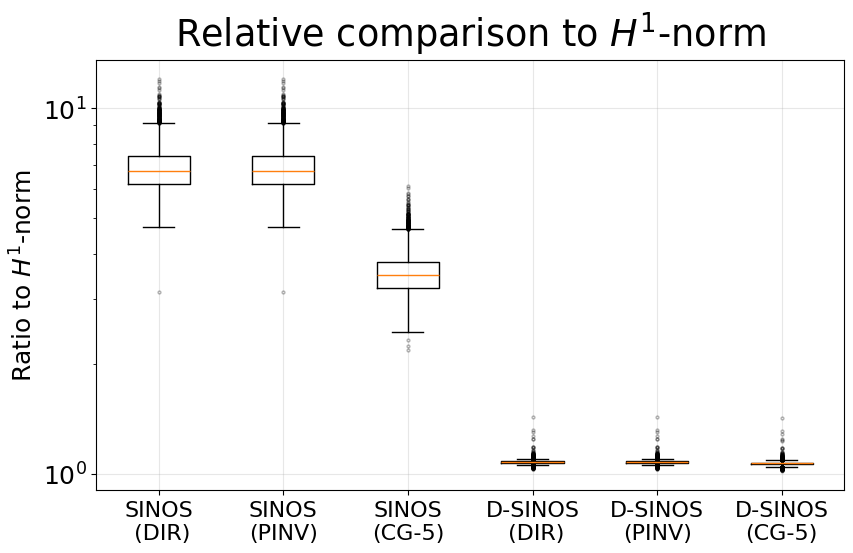

In [5]:
# We have to exclude NaN values of SINOS CG
mask = np.isfinite(results).all(axis=1)
ratios = results[mask]

# Re-ordering
perm = [0, 2, 4, 1, 3, 5]
ratios = ratios[:, perm]

plt.figure(figsize=(9, 6))

plt.boxplot(
    ratios,
    whis=1.5,
    tick_labels=[
        "SINOS\n (DIR)",
        "SINOS\n(PINV)",
        "SINOS\n(CG-5)",
        "D-SINOS\n (DIR)",
        "D-SINOS\n(PINV)",
        "D-SINOS\n(CG-5)",
    ],
    flierprops=dict(markersize=2, alpha=0.3),
)

plt.yscale("log")
plt.ylabel("Ratio to $H^1$-norm")
plt.title("Relative comparison to $H^1$-norm", pad=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("media/relative_comparsion_to_H1_norm.pdf", bbox_inches="tight", format="pdf")
plt.show()

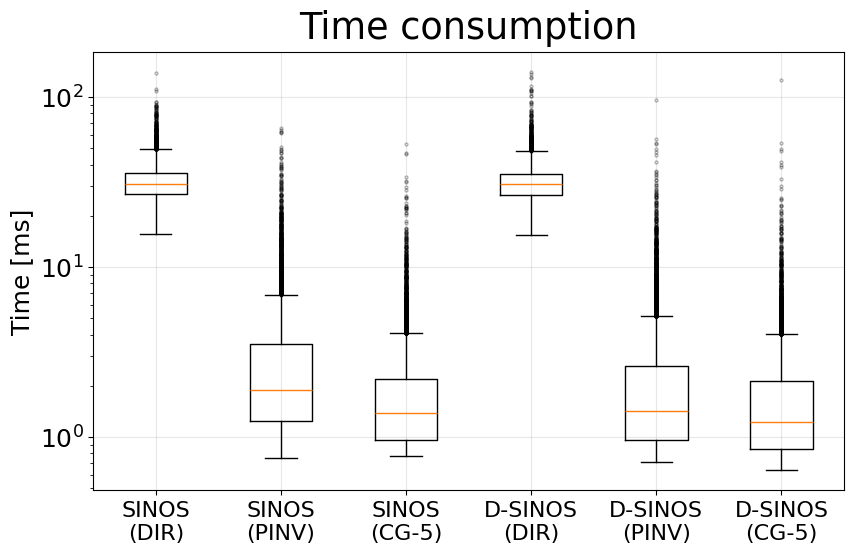

In [6]:
import matplotlib.pyplot as plt

# Re-ordering
perm = [0, 2, 4, 1, 3, 5]
times_perm = np.copy(times[:, perm])

plt.figure(figsize=(9, 6))

plt.boxplot(
    times_perm,
    whis=1.5,
    tick_labels=[
        "SINOS\n(DIR)",
        "SINOS\n(PINV)",
        "SINOS\n(CG-5)",
        "D-SINOS\n(DIR)",
        "D-SINOS\n(PINV)",
        "D-SINOS\n(CG-5)",
    ],
    flierprops=dict(markersize=2, alpha=0.3),
)
plt.yscale("log")
plt.ylabel("Time [ms]")
plt.title("Time consumption", pad=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("media/time_consumption.pdf", bbox_inches="tight", format="pdf")
plt.show()